<a href="https://colab.research.google.com/github/jskimn/aiservice_lesson2/blob/main/NNBasic/006_minist_pytorch/minist_twolayer_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PyTorch를 이용한 MNIST CNN**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from datetime import datetime

Device 설정

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


파라메터 설정

In [4]:
learning_rate = 0.001
batch = 32
epochs = 15

image_size = 32
nb_class = 10

MNIST 데이셋 로드

In [5]:
# transforms 정의하기
transforms = transforms.Compose([transforms.Resize((image_size, image_size)),
                                 transforms.ToTensor()])

# data set 다운받고 생성하기
train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transforms,
                               download=True)

valid_dataset = datasets.MNIST(root='./data',
                               train=False,
                               transform=transforms)

# data loader 정의하기
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch,
                          shuffle=True)

valid_loader = DataLoader(dataset=valid_dataset,
                          batch_size=batch,
                          shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.26MB/s]


신경망 모델 클래스 정의

In [7]:
class LeNet5(nn.Module):
    def __init__(self, n_classes):
        super(LeNet5, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=n_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return logits, probs

예측 정확도 측정 함수

In [8]:
def get_accuracy(model, data_loader, device):
    correct_pred = 0
    n = 0

    with torch.no_grad():
        model.eval()
        for X, y_true in data_loader:

            X = X.to(device)
            y_true = y_true.to(device)

            _, y_prob = model(X)
            _, predicted_labels = torch.max(y_prob, 1)

            n += y_true.size(0)
            correct_pred += (predicted_labels == y_true).sum()

    return correct_pred.float() / n

Loss 시각화 함수

In [9]:
def plot_losses(train_losses, valid_losses):
    train_losses = np.array(train_losses)
    valid_losses = np.array(valid_losses)

    fig, ax = plt.subplots(figsize = (8, 4.5))

    ax.plot(train_losses, color='blue', label='Training loss')
    ax.plot(valid_losses, color='red', label='Validation loss')
    ax.set(title="Loss over epochs",
            xlabel='Epoch',
            ylabel='Loss')
    ax.legend()
    fig.show()

    # plot style을 기본값으로 설정
    plt.style.use('default')

Train 함수

In [10]:
def train(train_loader, model, criterion, optimizer, device):
    model.train()
    running_loss = 0

    for X, y_true in train_loader:

        optimizer.zero_grad()

        X = X.to(device)
        y_true = y_true.to(device)

        # 순전파
        y_hat, _ = model(X)
        loss = criterion(y_hat, y_true)
        running_loss += loss.item() * X.size(0)

        # 역전파
        loss.backward()
        optimizer.step()

    epoch_loss = running_loss / len(train_loader.dataset)
    return model, optimizer, epoch_loss

Validation 함수

In [11]:
def validate(valid_loader, model, criterion, device):
    model.eval()
    running_loss = 0

    for X, y_true in valid_loader:

        X = X.to(device)
        y_true = y_true.to(device)

        # 순전파와 손실 기록하기
        y_hat, _ = model(X)
        loss = criterion(y_hat, y_true)
        running_loss += loss.item() * X.size(0)

    epoch_loss = running_loss / len(valid_loader.dataset)

    return model, epoch_loss

반복 학습 함수

In [12]:
def training_loop(model, criterion, optimizer, train_loader, valid_loader, epochs, device, print_every=1):
    # metrics를 저장하기 위한 객체 설정
    best_loss = 1e10
    train_losses = []
    valid_losses = []

    # model 학습하기
    for epoch in range(0, epochs):

        # training
        model, optimizer, train_loss = train(train_loader, model, criterion, optimizer, device)
        train_losses.append(train_loss)

        # validation
        with torch.no_grad():
            model, valid_loss = validate(valid_loader, model, criterion, device)
            valid_losses.append(valid_loss)

        if epoch % print_every == (print_every - 1):

            train_acc = get_accuracy(model, train_loader, device=device)
            valid_acc = get_accuracy(model, valid_loader, device=device)

            print(f'{datetime.now().time().replace(microsecond=0)} --- '
                  f'Epoch: {epoch}\t'
                  f'Train loss: {train_loss:.4f}\t'
                  f'Valid loss: {valid_loss:.4f}\t'
                  f'Train accuracy: {100 * train_acc:.2f}\t'
                  f'Valid accuracy: {100 * valid_acc:.2f}')

    plot_losses(train_losses, valid_losses)

    return model, optimizer, (train_losses, valid_losses)

07:12:59 --- Epoch: 0	Train loss: 0.2363	Valid loss: 0.0832	Train accuracy: 97.46	Valid accuracy: 97.53
07:13:25 --- Epoch: 1	Train loss: 0.0821	Valid loss: 0.0676	Train accuracy: 98.30	Valid accuracy: 97.96
07:13:50 --- Epoch: 2	Train loss: 0.0565	Valid loss: 0.0567	Train accuracy: 98.67	Valid accuracy: 98.25
07:14:15 --- Epoch: 3	Train loss: 0.0442	Valid loss: 0.0571	Train accuracy: 98.94	Valid accuracy: 98.29
07:14:40 --- Epoch: 4	Train loss: 0.0367	Valid loss: 0.0507	Train accuracy: 99.10	Valid accuracy: 98.45
07:15:05 --- Epoch: 5	Train loss: 0.0299	Valid loss: 0.0471	Train accuracy: 99.30	Valid accuracy: 98.54
07:15:30 --- Epoch: 6	Train loss: 0.0264	Valid loss: 0.0482	Train accuracy: 99.22	Valid accuracy: 98.45
07:15:55 --- Epoch: 7	Train loss: 0.0219	Valid loss: 0.0531	Train accuracy: 99.37	Valid accuracy: 98.44
07:16:22 --- Epoch: 8	Train loss: 0.0190	Valid loss: 0.0512	Train accuracy: 99.38	Valid accuracy: 98.53
07:16:48 --- Epoch: 9	Train loss: 0.0179	Valid loss: 0.0602	Trai

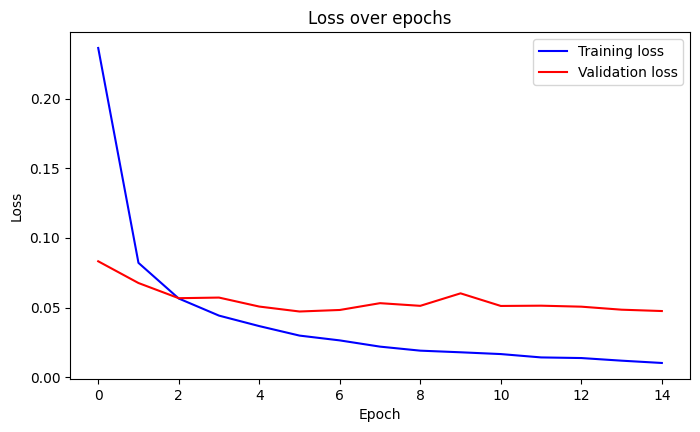

In [14]:
#RANDOM_SEED = 42
#torch.manual_seed(RANDOM_SEED)

model = LeNet5(nb_class).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()


model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader,
                                    valid_loader, epochs, device)